In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import duckdb
import seaborn as sns
sns.set_theme(style='ticks', font_scale=2.3, palette=sns.color_palette(),)
import matplotlib.pyplot as plt
import polars as pl
import torch
import numpy as np

import conf.conf
import dafm.datasets
import dafm.observe
import dafm.plots
import dafm.utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
attach '../optuna.sqlite';
use runs;
""")

### Training Dynamical System

##### Lorenz '63

In [4]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_lorenz63spantini2022_identity_obs
where rng_seed = 2376999025
and ReferenceFilter is not null
""")
da_setting_rows

┌─────────────────────────────────────┬─────────────────────────┬────────────────┬───────────────┬────────────┬────────────────────────────┬─────────────────┐
│            setting_name             │ DataAssimilationSetting │ time_step_size │ obs_noise_std │  rng_seed  │ observe_every_n_time_steps │ ReferenceFilter │
│               varchar               │          int64          │     double     │    double     │   int64    │           int64            │      int64      │
├─────────────────────────────────────┼─────────────────────────┼────────────────┼───────────────┼────────────┼────────────────────────────┼─────────────────┤
│ Lorenz63Spantini2022IdentityObsDim3 │                      17 │           0.05 │           2.0 │ 2376999025 │                         16 │            6815 │
│ Lorenz63Spantini2022IdentityObsDim3 │                       7 │           0.05 │           2.0 │ 2376999025 │                          8 │            1807 │
│ Lorenz63Spantini2022IdentityObsDim3 │       

In [19]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_lorenz63spantini2022_atan_obs
where rng_seed = 2376999025
and ReferenceFilter is not null
""")
da_setting_rows

┌─────────────────────────────────┬─────────────────────────┬────────────────┬───────────────┬────────────┬────────────────────────────┬─────────────────┐
│          setting_name           │ DataAssimilationSetting │ time_step_size │ obs_noise_std │  rng_seed  │ observe_every_n_time_steps │ ReferenceFilter │
│             varchar             │          int64          │     double     │    double     │   int64    │           int64            │      int64      │
├─────────────────────────────────┼─────────────────────────┼────────────────┼───────────────┼────────────┼────────────────────────────┼─────────────────┤
│ Lorenz63Spantini2022ATanObsDim3 │                      50 │           0.05 │           0.1 │ 2376999025 │                         16 │            7989 │
│ Lorenz63Spantini2022ATanObsDim3 │                      41 │           0.05 │           0.1 │ 2376999025 │                          8 │            7982 │
│ Lorenz63Spantini2022ATanObsDim3 │                      40 │         

### Evaluation Dynamical System

In [20]:
_eval_da_setting_rows = da_setting_rows

In [21]:
eval_da_setting_rows = duckdb.sql("""
select
    target_id as training_data_assimilation_setting_id,
    source_id as DataAssimilationSetting,
    DynamicalSystemImpl.rng_seed,
    data_assimilation_settings_same.* exclude(target_id, source_id),
    reference_filter.alt_id as reference_filter,
from _eval_da_setting_rows
join data_assimilation_settings_same on _eval_da_setting_rows.DataAssimilationSetting = target_id
join DataAssimilationSetting on source_id = DataAssimilationSetting.id
join DynamicalSystemImpl on DataAssimilationSetting.DynamicalSystemImpl = DynamicalSystemImpl.id
join Conf as reference_filter on DataAssimilationSetting.ReferenceFilter = reference_filter.id
where DynamicalSystemImpl.rng_seed in (select rng_seed from RngSeed where split = 'TEST')
--and DataAssimilationSetting.ReferenceFilter is not null
""")
eval_da_setting_rows.show(max_width=120)

┌──────────────────────┬──────────────────────┬───┬──────────────────────┬─────────────────────┬──────────────────┐
│ training_data_assi…  │ DataAssimilationSe…  │ … │ ensemble_initial_m…  │ dynamical_system_id │ reference_filter │
│        int64         │        int64         │   │        int64         │        int64        │     varchar      │
├──────────────────────┼──────────────────────┼───┼──────────────────────┼─────────────────────┼──────────────────┤
│                   50 │                  139 │ … │                    1 │                   1 │ bijhzmpq         │
│                   41 │                  156 │ … │                    1 │                   1 │ 2cdy5u7m         │
│                   39 │                  169 │ … │                    1 │                   1 │ 71d80xvq         │
│                   39 │                  105 │ … │                    1 │                   1 │ su0re8f1         │
│                   40 │                  184 │ … │                    1

# Load runs

In [22]:
filters = duckdb.sql("""
select
    Filter, filter_name,
from to_plot_classical_filter
where filter_name = 'EnKF-PO'
and localization is null
union
select
    Filter, filter_name,
from to_plot_generative_filter
""")
filters

┌──────────┬─────────────┐
│  Filter  │ filter_name │
│  int64   │   varchar   │
├──────────┼─────────────┤
│    13920 │ EnSF        │
│    14264 │ EnSF        │
│    15659 │ EnSF        │
│    16437 │ EnSF        │
│    16522 │ EnSF        │
│    17337 │ EnSF        │
│    17358 │ EnSF        │
│    17651 │ EnSF        │
│    20290 │ EnSF        │
│    20656 │ EnSF        │
│      ·   │  ·          │
│      ·   │  ·          │
│      ·   │  ·          │
│    15486 │ EnFF-F2P    │
│    15573 │ EnFF-OT     │
│    15812 │ EnFF-F2P    │
│    15896 │ EnFF-F2P    │
│    16000 │ EnFF-F2P    │
│    16482 │ EnFF-F2P    │
│    18247 │ EnFF-F2P    │
│    18335 │ EnFF-F2P    │
│    18458 │ EnFF-OT     │
│    18783 │ EnFF-F2P    │
├──────────┴─────────────┤
│ ? rows       2 columns │
└────────────────────────┘

In [23]:
training_generative_filter_rows = duckdb.sql("""
select
    DataAssimilationSetting,
    setting_name,
    trial_alt_id,
    Filter,
    filter_name,
from OptunaStudy
join optuna.best_study_trials on OptunaStudy.alt_id = study_alt_id
join optuna.trial_values using (trial_id)
join Conf on BaseConf = Conf.id
join da_setting_rows using (DataAssimilationSetting)
join filters using (Filter)
where tie_breaker = 1
qualify dense_rank() over (partition by DataAssimilationSetting, filter_name order by value) = 1
""")
training_generative_filter_rows.show(max_width=120)

┌─────────────────────────┬─────────────────────────────────┬──────────────┬────────┬─────────────┐
│ DataAssimilationSetting │          setting_name           │ trial_alt_id │ Filter │ filter_name │
│          int64          │             varchar             │   varchar    │ int64  │   varchar   │
├─────────────────────────┼─────────────────────────────────┼──────────────┼────────┼─────────────┤
│                      41 │ Lorenz63Spantini2022ATanObsDim3 │ de06detd     │  13187 │ EnFF-OT     │
│                      40 │ Lorenz63Spantini2022ATanObsDim3 │ 217opwhy     │  23722 │ EnSF        │
│                      39 │ Lorenz63Spantini2022ATanObsDim3 │ rnxbnvj4     │  13187 │ EnFF-OT     │
│                      39 │ Lorenz63Spantini2022ATanObsDim3 │ jvmp0m33     │  13238 │ EnFF-F2P    │
│                      50 │ Lorenz63Spantini2022ATanObsDim3 │ 3ugc4o8o     │  13238 │ EnFF-F2P    │
│                      39 │ Lorenz63Spantini2022ATanObsDim3 │ 2crqs2sx     │  13539 │ EnSF        │


In [24]:
training_enkf_rows = duckdb.sql("""
select
    DataAssimilationSetting,
    setting_name,
    alt_id as trial_alt_id,
    Filter,
    filter_name,
from filters
join Conf using (Filter)
join da_setting_rows using (DataAssimilationSetting)
where filter_name = 'EnKF-PO'
and not save_ensemble_stats
""")
training_enkf_rows

┌─────────────────────────┬─────────────────────────────────┬──────────────┬────────┬─────────────┐
│ DataAssimilationSetting │          setting_name           │ trial_alt_id │ Filter │ filter_name │
│          int64          │             varchar             │   varchar    │ int64  │   varchar   │
├─────────────────────────┼─────────────────────────────────┼──────────────┼────────┼─────────────┤
│                      40 │ Lorenz63Spantini2022ATanObsDim3 │ 9yjhp59d     │   5560 │ EnKF-PO     │
│                      39 │ Lorenz63Spantini2022ATanObsDim3 │ ok4kyyhy     │   5560 │ EnKF-PO     │
│                      41 │ Lorenz63Spantini2022ATanObsDim3 │ t9gue0ee     │   5560 │ EnKF-PO     │
│                      50 │ Lorenz63Spantini2022ATanObsDim3 │ 07pb3c4t     │   5560 │ EnKF-PO     │
└─────────────────────────┴─────────────────────────────────┴──────────────┴────────┴─────────────┘

In [25]:
training_rows = duckdb.sql("""
select
    *
from training_enkf_rows
union
select
    *
from training_generative_filter_rows
""")
training_rows

┌─────────────────────────┬─────────────────────────────────┬──────────────┬────────┬─────────────┐
│ DataAssimilationSetting │          setting_name           │ trial_alt_id │ Filter │ filter_name │
│          int64          │             varchar             │   varchar    │ int64  │   varchar   │
├─────────────────────────┼─────────────────────────────────┼──────────────┼────────┼─────────────┤
│                      39 │ Lorenz63Spantini2022ATanObsDim3 │ ok4kyyhy     │   5560 │ EnKF-PO     │
│                      50 │ Lorenz63Spantini2022ATanObsDim3 │ 862tq62d     │  13187 │ EnFF-OT     │
│                      39 │ Lorenz63Spantini2022ATanObsDim3 │ 2crqs2sx     │  13539 │ EnSF        │
│                      40 │ Lorenz63Spantini2022ATanObsDim3 │ 898mnv8i     │  13238 │ EnFF-F2P    │
│                      41 │ Lorenz63Spantini2022ATanObsDim3 │ de06detd     │  13187 │ EnFF-OT     │
│                      40 │ Lorenz63Spantini2022ATanObsDim3 │ 9yjhp59d     │   5560 │ EnKF-PO     │


In [26]:
train_to_test_row_map = duckdb.sql("""
select
    training_rows.DataAssimilationSetting as training_data_assimilation_setting_id,
    training_rows.setting_name,
    eval_da_setting_rows.DataAssimilationSetting as testing_data_assimilation_setting_id,
    testing_alt_id as alt_id,
    testing_rng_seed,
    training_alt_id,
    training_rows.Filter,
    eval_da_setting_rows.reference_filter as testing_reference_filter,
from training_rows
join training_conf_to_testing_conf on trial_alt_id = training_alt_id
join Conf as testing_conf on testing_alt_id = testing_conf.alt_id
join eval_da_setting_rows on testing_conf.DataAssimilationSetting = eval_da_setting_rows.DataAssimilationSetting
""")
train_to_test_row_map

┌───────────────────────────────────────┬─────────────────────────────────┬──────────────────────────────────────┬──────────┬──────────────────┬─────────────────┬────────┬──────────────────────────┐
│ training_data_assimilation_setting_id │          setting_name           │ testing_data_assimilation_setting_id │  alt_id  │ testing_rng_seed │ training_alt_id │ Filter │ testing_reference_filter │
│                 int64                 │             varchar             │                int64                 │ varchar  │      int64       │     varchar     │ int64  │         varchar          │
├───────────────────────────────────────┼─────────────────────────────────┼──────────────────────────────────────┼──────────┼──────────────────┼─────────────────┼────────┼──────────────────────────┤
│                                    41 │ Lorenz63Spantini2022ATanObsDim3 │                                  130 │ xtuy0th5 │        979497033 │ de06detd        │  13187 │ w8ytngpk                 │
│    

In [27]:
missing_testing_rows = duckdb.sql("""
with required_rows as (
    select
        trial_alt_id as alt_id,
        DynamicalSystemImpl.rng_seed,
        training_rows.DataAssimilationSetting as training_data_assimilation_setting_id,
        reference_filter.alt_id as testing_reference_filter,
    from training_rows
    join _eval_da_setting_rows using (DataAssimilationSetting)
    join data_assimilation_settings_same on _eval_da_setting_rows.DataAssimilationSetting = target_id
    join DataAssimilationSetting testing_da_setting on source_id = testing_da_setting.id
    join DynamicalSystemImpl on testing_da_setting.DynamicalSystemImpl = DynamicalSystemImpl.id
    join Conf as reference_filter on testing_da_setting.ReferenceFilter = reference_filter.id
)
select
    *,
from required_rows
where training_data_assimilation_setting_id not in (select training_data_assimilation_setting_id from eval_da_setting_rows)
union
select * from (
    select * from required_rows
    except
    select
        training_alt_id,
        train_to_test_row_map.testing_rng_seed,
        eval_da_setting_rows.training_data_assimilation_setting_id,
        train_to_test_row_map.testing_reference_filter,
    from train_to_test_row_map
    join eval_da_setting_rows on train_to_test_row_map.testing_data_assimilation_setting_id = eval_da_setting_rows.DataAssimilationSetting
        and train_to_test_row_map.testing_rng_seed = eval_da_setting_rows.rng_seed
)
""")
missing_testing_rows.show()
assert len(missing_testing_rows) == 0
missing_testing_rows.pl().with_columns(reference_filter=pl.lit('None')).write_csv('reruns.csv')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬──────────┬───────────────────────────────────────┬──────────────────────────┐
│ alt_id  │ rng_seed │ training_data_assimilation_setting_id │ testing_reference_filter │
│ varchar │  int64   │                 int64                 │         varchar          │
├─────────┴──────────┴───────────────────────────────────────┴──────────────────────────┤
│                                        0 rows                                         │
└───────────────────────────────────────────────────────────────────────────────────────┘



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [28]:
to_plot_x = duckdb.sql("""
select
    train_to_test_row_map.alt_id,
    observe_every_n_time_steps * time_step_size as x,
from train_to_test_row_map
join Conf using (alt_id)
join data_assimilation_setting on DataAssimilationSetting = data_assimilation_setting_id
join DynamicalSystem on dynamical_system_id = DynamicalSystem.id
""")
to_plot_x

┌──────────┬────────┐
│  alt_id  │   x    │
│ varchar  │ double │
├──────────┼────────┤
│ nwx65rga │    0.1 │
│ z4kqjidi │    0.8 │
│ qxauae89 │    0.1 │
│ qpvvg4w2 │    0.8 │
│ fk58ku4c │    0.1 │
│ lrc8d8fe │    0.8 │
│ n1f3i182 │    0.1 │
│ e6xm6l0c │    0.8 │
│ 4plkh58y │    0.1 │
│ 6k3v9vm3 │    0.8 │
│    ·     │     ·  │
│    ·     │     ·  │
│    ·     │     ·  │
│ xlg0uu58 │    0.1 │
│ txmgsxyj │    0.4 │
│ ggy4k9as │    0.1 │
│ 1wi77gdt │    0.4 │
│ ig1ef4o0 │    0.1 │
│ 70ow35n2 │    0.4 │
│ qui42mwb │    0.1 │
│ tvt8oi29 │    0.4 │
│ cr5pksag │    0.1 │
│ zkon3wt3 │    0.4 │
├──────────┴────────┤
│      80 rows      │
│    (20 shown)     │
└───────────────────┘

In [29]:
to_plot_hue_style = duckdb.sql("""
select
    alt_id,
    filter_name as hue,
    hue as style,
from train_to_test_row_map
join (
    select Filter, filter_name from to_plot_generative_filter
    union
    select Filter, filter_name from to_plot_classical_filter
) using (Filter)
""")
to_plot_hue_style

┌──────────┬──────────┬──────────┐
│  alt_id  │   hue    │  style   │
│ varchar  │ varchar  │ varchar  │
├──────────┼──────────┼──────────┤
│ atfmffgx │ EnKF-PO  │ EnKF-PO  │
│ 3kuvcvbs │ EnSF     │ EnSF     │
│ cr5pksag │ EnFF-F2P │ EnFF-F2P │
│ xlg0uu58 │ EnFF-F2P │ EnFF-F2P │
│ qkzgbkjn │ EnSF     │ EnSF     │
│ 38onafnd │ EnKF-PO  │ EnKF-PO  │
│ 4990t1rt │ EnSF     │ EnSF     │
│ chrk5uon │ EnSF     │ EnSF     │
│ hv1ve3ss │ EnSF     │ EnSF     │
│ iff5anq3 │ EnSF     │ EnSF     │
│    ·     │  ·       │  ·       │
│    ·     │  ·       │  ·       │
│    ·     │  ·       │  ·       │
│ e6xm6l0c │ EnFF-OT  │ EnFF-OT  │
│ qxauae89 │ EnKF-PO  │ EnKF-PO  │
│ qpvvg4w2 │ EnFF-OT  │ EnFF-OT  │
│ 3mnt49u6 │ EnKF-PO  │ EnKF-PO  │
│ 4plkh58y │ EnKF-PO  │ EnKF-PO  │
│ fk58ku4c │ EnKF-PO  │ EnKF-PO  │
│ z4kqjidi │ EnFF-OT  │ EnFF-OT  │
│ 8x5j14tj │ EnFF-OT  │ EnFF-OT  │
│ 2i95a7pb │ EnKF-PO  │ EnKF-PO  │
│ t3ob44ho │ EnKF-PO  │ EnKF-PO  │
├──────────┴──────────┴──────────┤
│ 80 rows (20 shown)

In [30]:
to_plot_y = dafm.plots.get_logged_metrics(train_to_test_row_map).pl()
to_plot_y = duckdb.sql("""
with max_steps as (
    select
        alt_id,
        max(step) as max_step,
    from to_plot_y
    group by alt_id
)
unpivot (
    select
        alt_id,
        mean(rmse_from_reference_filter) as mean_rmse,
        mean(energy_score_from_reference_filter) as mean_energy_score,
    from to_plot_y
    join max_steps using (alt_id)
    where step >= max_step - 50
    group by alt_id
)
on mean_rmse, mean_energy_score
into name row value y
""")
to_plot_y

┌──────────┬───────────────────┬────────────────────┐
│  alt_id  │        row        │         y          │
│ varchar  │      varchar      │       double       │
├──────────┼───────────────────┼────────────────────┤
│ grywmmom │ mean_rmse         │                nan │
│ grywmmom │ mean_energy_score │                nan │
│ gp2cbaum │ mean_rmse         │ 3.7049229711878535 │
│ gp2cbaum │ mean_energy_score │  6.300892412516416 │
│ psprfudm │ mean_rmse         │ 0.5884307753659931 │
│ psprfudm │ mean_energy_score │ 1.0024628199490846 │
│ lp3mqf9k │ mean_rmse         │  5.972455387021981 │
│ lp3mqf9k │ mean_energy_score │ 7.4604664035871915 │
│ y3wycvm4 │ mean_rmse         │                nan │
│ y3wycvm4 │ mean_energy_score │                nan │
│    ·     │     ·             │                 ·  │
│    ·     │     ·             │                 ·  │
│    ·     │     ·             │                 ·  │
│ qxauae89 │ mean_rmse         │ 0.4105280650889172 │
│ qxauae89 │ mean_energy_sco

In [31]:
to_plot = duckdb.sql("""
select
    *
from to_plot_x
join to_plot_hue_style using (alt_id)
join to_plot_y using (alt_id)
""").pl()
to_plot

alt_id,x,hue,style,row,y
str,f64,str,str,str,f64
"""atfmffgx""",0.8,"""EnKF-PO""","""EnKF-PO""","""mean_rmse""",NaN
"""tvt8oi29""",0.4,"""EnFF-F2P""","""EnFF-F2P""","""mean_rmse""",2.652629
"""cr5pksag""",0.1,"""EnFF-F2P""","""EnFF-F2P""","""mean_rmse""",0.497232
"""xlg0uu58""",0.1,"""EnFF-F2P""","""EnFF-F2P""","""mean_rmse""",0.536238
"""qkzgbkjn""",0.2,"""EnSF""","""EnSF""","""mean_rmse""",2.079608
…,…,…,…,…,…
"""t3ob44ho""",0.4,"""EnKF-PO""","""EnKF-PO""","""mean_energy_score""",5.01751
"""4990t1rt""",0.4,"""EnSF""","""EnSF""","""mean_energy_score""",10.508681
"""psprfudm""",0.1,"""EnFF-OT""","""EnFF-OT""","""mean_energy_score""",1.002463


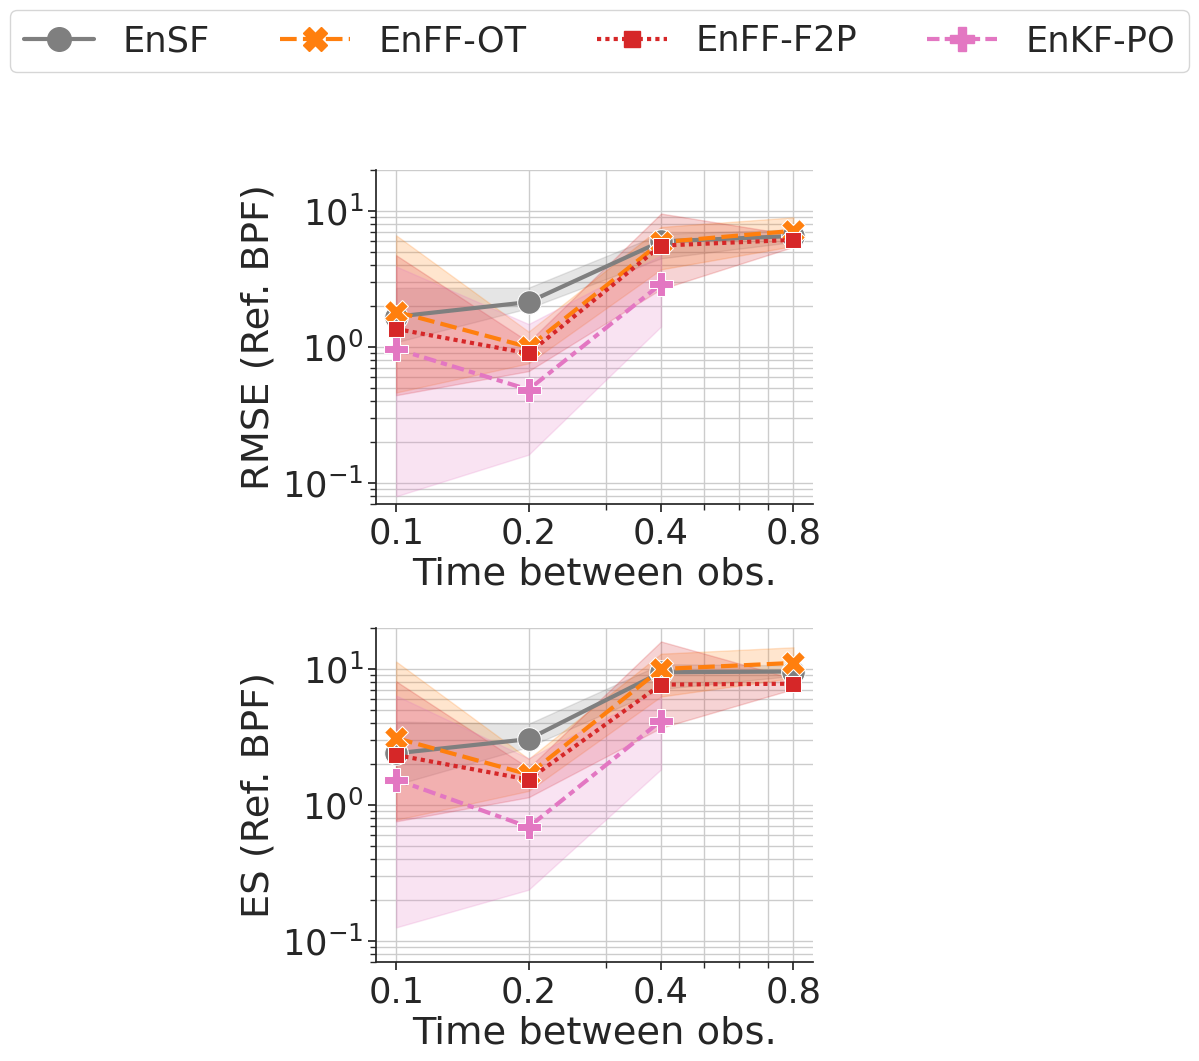

In [32]:
order = sorted(to_plot['hue'].unique(), key=dafm.plots.FILTER_ORDER.get)
plot = (
    sns.relplot(
        kind='line',
        estimator='mean',
        errorbar=('pi', 100),
        data=to_plot.to_pandas(),
        **{k: k if k != 'style' else 'hue' for k in to_plot.columns if k != 'alt_id'},
        hue_order=order,
        style_order=order,
        palette=dafm.plots.FILTER_PALETTE,
        markers=True,
        linewidth=3,
        markersize=17,
        aspect=1.3,
        facet_kws=dict(
            sharex=False,
        ),
    )
    .set_titles('')
    .set(
        xscale='log',
        xlabel='Time between obs.',
        yscale='log',
        ylim=(.07, 20),
        xticks=to_plot['x'].unique(),
        xticklabels=to_plot['x'].unique(),
    )
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)
for (row, col, hue), _ in plot.facet_data():
    ax = plot.axes[row, col]
    ax.grid()
    ax.grid(which='minor')
    ax.tick_params(axis='both', which='minor', labelbottom=False)
    metric = plot.row_names[row]
    if metric == 'mean_rmse':
        ylabel = 'RMSE (Ref. BPF)'
    elif metric == 'mean_energy_score':
        ylabel = 'ES (Ref. BPF)'
    else:
        raise ValueError(f'Unknown metric: {metric}')
    ax.set_ylabel(ylabel)

In [33]:
dafm.plots.save_all_subfigures(plot, 'Ablation')